# Предобработка датасета о фильмах

Датасет: [Movies Dataset for Feature Extracion, Prediction](https://www.kaggle.com/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction) (Kaggle).

Цель — очистить и преобразовать «сырые» данные, собранные с IMDb, в табличный формат, пригодный для обучения ML-моделей: разобрать смешанные текстовые поля, обработать пропуски и выбросы, закодировать категориальные признаки.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

## 1. Загрузка данных

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bharatnatrayn/movies-dataset-for-feature-extracion-prediction")

print("Path to dataset files:", path)

Path to dataset files: /Users/liliya/.cache/kagglehub/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction/versions/1


In [3]:
df = pd.read_csv(f"{path}/movies.csv")
df.shape

(9999, 9)

## 2. Первичный осмотр данных

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


In [5]:
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [6]:
print("Пропуски по столбцам:")
df.isna().sum()

Пропуски по столбцам:


MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

In [7]:
print("Полных дублей строк:", df.duplicated().sum())
df = df.drop_duplicates()
df.shape

Полных дублей строк: 431


(9568, 9)

Больше всего пропусков в `Gross` (сборы) и `RunTime`/`RATING`/`VOTES`. Строковые поля (`MOVIES`, `GENRE`, `ONE-LINE`, `STARS`) содержат служебные символы `\n`, оставшиеся после скрапинга — их нужно убрать перед дальнейшей обработкой.

## 3. Очистка текстовых полей

In [8]:
for col in ['MOVIES', 'GENRE', 'ONE-LINE']:
    df[col] = df[col].str.strip()

df[['MOVIES', 'GENRE', 'ONE-LINE']].head()

,MOVIES,GENRE,ONE-LINE
0,Blood Red Sky,"Action, Horror, Thriller",A woman with a mysterious illness is forced in...
1,Masters of the Universe: Revelation,"Animation, Action, Adventure",The war for Eternia begins again in what may b...
2,The Walking Dead,"Drama, Horror, Thriller",Sheriff Deputy Rick Grimes wakes up from a com...
3,Rick and Morty,"Animation, Adventure, Comedy",An animated series that follows the exploits o...
4,Army of Thieves,"Action, Crime, Horror","A prequel, set before the events of Army of th..."


## 4. Год выпуска (`YEAR`)

Поле хранит либо год фильма `(2021)`, либо диапазон лет сериала `(2010–2022)`, либо ещё идущий сериал `(2013– )`. Разбираем его на:
- `year_start` — год начала;
- `year_end` — год окончания (если есть);
- `is_series` — флаг сериала (наличие тире в исходной строке).

In [9]:
years = df['YEAR'].str.findall(r'\d{4}')
years = years.apply(lambda x: x if isinstance(x, list) else [])

df['year_start'] = years.apply(lambda x: int(x[0]) if x else np.nan)
df['year_end'] = years.apply(lambda x: int(x[1]) if len(x) > 1 else np.nan)
df['is_series'] = df['YEAR'].str.contains('–', na=False).astype(int)

df = df.drop(columns=['YEAR'])
print("Пропусков в year_start:", df['year_start'].isna().sum())

Пропусков в year_start: 635


In [10]:
# без года фильм невозможно надёжно сопоставить с эпохой/контекстом — строки с пропуском отбрасываем
df = df.dropna(subset=['year_start'])
df['year_start'] = df['year_start'].astype(int)
df.shape

(8933, 11)

## 5. Режиссёр и актёрский состав (`STARS`)

Поле `STARS` — это неструктурированный блок текста вида:

```
Director:
Peter Thorwarth
|
Stars:
Peri Baumeister, Carl Anton Koch, ...
```

Для сериалов режиссёр часто не указан. Извлекаем режиссёра и список актёров регулярными выражениями, затем превращаем их в числовые признаки: частоту режиссёра (сколько фильмов/сериалов в датасете с ним связано) и количество перечисленных актёров.

In [11]:
director = df['STARS'].str.extract(r'Director[s]?:\n(.*?)\n\|')[0].str.strip()
stars_raw = df['STARS'].str.extract(r'Stars:\n(.*)', flags=re.S)[0]
stars_list = stars_raw.str.split(',').apply(
    lambda lst: [s.strip() for s in lst if s.strip()] if isinstance(lst, list) else []
)

df['director'] = director.fillna('Unknown')
df['num_stars'] = stars_list.apply(len)

# частоту считаем только по известным режиссёрам, чтобы "Unknown" не выглядел
# как самый "продуктивный" режиссёр
known_dir_freq = df.loc[df['director'] != 'Unknown', 'director'].value_counts()
df['director_freq'] = df['director'].map(known_dir_freq).fillna(0).astype(int)
df['director_is_known'] = (df['director'] != 'Unknown').astype(int)

df[['director', 'director_freq', 'director_is_known', 'num_stars']].head()

,director,director_freq,director_is_known,num_stars
0,Peter Thorwarth,1,1,4
1,Unknown,0,0,4
2,Unknown,0,0,4
3,Unknown,0,0,4
4,Matthias Schweighöfer,1,1,4


## 6. Количество голосов (`VOTES`)

In [12]:
df['VOTES'] = df['VOTES'].str.replace(',', '', regex=False).astype(float)

df['votes_is_missing'] = df['VOTES'].isna().astype(int)
df['VOTES'] = df['VOTES'].fillna(df['VOTES'].median())

# распределение сильно скошено вправо -> логарифмируем
df['votes_log'] = np.log1p(df['VOTES'])
df[['VOTES', 'votes_log', 'votes_is_missing']].describe()

,VOTES,votes_log,votes_is_missing
count,8.933000e+03,8933.000000,8933.000000
mean,1.391535e+04,6.807646,0.085638
std,6.715066e+04,2.215901,0.279844
min,5.000000e+00,1.791759,0.000000
25%,1.970000e+02,5.288267,0.000000
50%,7.925000e+02,6.676454,0.000000
75%,3.267000e+03,8.091933,0.000000
max,1.713028e+06,14.353774,1.000000


## 7. Продолжительность (`RunTime`): пропуски и выбросы

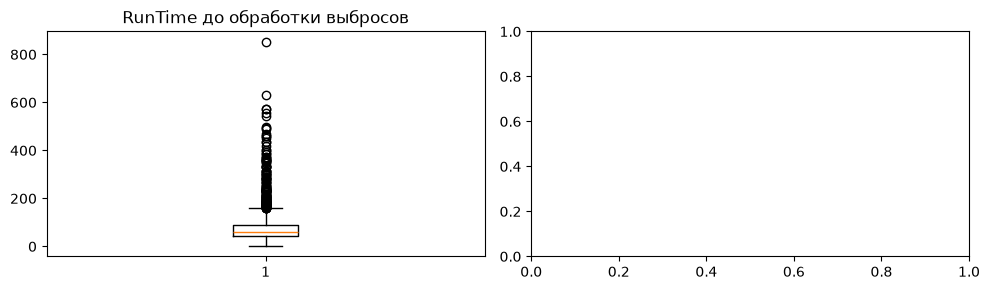

In [13]:
df['runtime_is_missing'] = df['RunTime'].isna().astype(int)
df['RunTime'] = df['RunTime'].fillna(df['RunTime'].median())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].boxplot(df['RunTime'])
axes[0].set_title('RunTime до обработки выбросов')
plt.tight_layout()

In [14]:
q1, q3 = df['RunTime'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = max(q1 - 1.5 * iqr, 0)
upper = q3 + 1.5 * iqr
print(f"Границы IQR: [{lower:.1f}, {upper:.1f}]; выбросов: {((df['RunTime'] < lower) | (df['RunTime'] > upper)).sum()}")

df['RunTime'] = df['RunTime'].clip(lower, upper)

Границы IQR: [0.0, 160.5]; выбросов: 137


## 8. Сборы (`Gross`)

Проверим долю пропусков — если признак почти пустой, использовать его в модели бессмысленно.

In [15]:
missing_share = df['Gross'].isna().mean()
print(f"Доля пропусков в Gross: {missing_share:.1%}")

# > 95% пропусков — признак неинформативен, удаляем колонку целиком
df = df.drop(columns=['Gross'])

Доля пропусков в Gross: 94.9%


## 9. Целевая переменная (`RATING`)

`RATING` — наиболее вероятная целевая переменная для регрессии. Обучать модель на строках без целевого значения нельзя, поэтому такие строки удаляем (а не заполняем — это исказило бы обучение).

In [16]:
missing_share = df['RATING'].isna().mean()
print(f"Доля пропусков в RATING: {missing_share:.1%}")

before = df.shape[0]
df = df.dropna(subset=['RATING'])
print(f"Удалено строк без RATING: {before - df.shape[0]}")

Доля пропусков в RATING: 8.6%
Удалено строк без RATING: 765


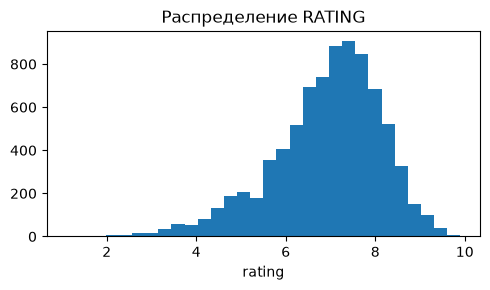

In [17]:
plt.figure(figsize=(5, 3))
plt.hist(df['RATING'], bins=30)
plt.title('Распределение RATING')
plt.xlabel('rating')
plt.tight_layout()

## 10. Кодирование жанров (`GENRE`)

У фильма может быть несколько жанров одновременно, поэтому используем multi-label one-hot encoding (по одному бинарному столбцу на жанр).

In [18]:
df['GENRE'] = df['GENRE'].fillna('Unknown')
genre_dummies = df['GENRE'].str.get_dummies(sep=', ')
genre_dummies.columns = [
    'genre_' + c.lower().replace('-', '_').replace(' ', '_') for c in genre_dummies.columns
]
genre_dummies.shape

(8168, 28)

## 11. Сборка финального датасета

In [19]:
final_df = pd.concat(
    [
        df[[
            'MOVIES', 'year_start', 'is_series', 'RATING', 'RunTime', 'runtime_is_missing',
            'VOTES', 'votes_log', 'votes_is_missing', 'num_stars',
            'director_freq', 'director_is_known',
        ]],
        genre_dummies,
    ],
    axis=1,
).reset_index(drop=True)

final_df = final_df.rename(columns={'RATING': 'rating', 'RunTime': 'runtime', 'VOTES': 'votes'})
final_df.shape

(8168, 40)

**Комментарий по составу финального датасета:**
- `MOVIES` оставлен как идентификатор строки (не признак для модели, при обучении его нужно исключить из X);
- `rating` — целевая переменная;
- числовые признаки (`year_start`, `runtime`, `votes`, `votes_log`, `num_stars`, `director_freq`) очищены от пропусков и выбросов;
- `is_series`, `runtime_is_missing`, `votes_is_missing`, `director_is_known` — бинарные признаки;
- `genre_*` — one-hot колонки по жанрам;
- `ONE-LINE` и исходный `STARS` не включены в финальный датасет — это свободный текст, для его использования потребуется отдельная NLP-векторизация (TF-IDF/эмбеддинги), выходящая за рамки табличной предобработки.

## 12. Проверка итогового датасета

In [20]:
print("Пропусков в итоговом датасете:", final_df.isna().sum().sum())
final_df.dtypes

Пропусков в итоговом датасете: 0


MOVIES                    str
year_start              int64
is_series               int64
rating                float64
runtime               float64
runtime_is_missing      int64
votes                 float64
votes_log             float64
votes_is_missing        int64
num_stars               int64
director_freq           int64
director_is_known       int64
genre_action            int64
genre_adventure         int64
genre_animation         int64
genre_biography         int64
genre_comedy            int64
genre_crime             int64
genre_documentary       int64
genre_drama             int64
genre_family            int64
genre_fantasy           int64
genre_film_noir         int64
genre_game_show         int64
genre_history           int64
genre_horror            int64
genre_music             int64
genre_musical           int64
genre_mystery           int64
genre_news              int64
genre_reality_tv        int64
genre_romance           int64
genre_sci_fi            int64
genre_shor

## Финальный датасет

In [21]:
final_df.head(10)

,MOVIES,year_start,is_series,rating,runtime,runtime_is_missing,votes,votes_log,votes_is_missing,num_stars,director_freq,director_is_known,genre_action,genre_adventure,genre_animation,genre_biography,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,genre_fantasy,genre_film_noir,genre_game_show,genre_history,genre_horror,genre_music,genre_musical,genre_mystery,genre_news,genre_reality_tv,genre_romance,genre_sci_fi,genre_short,genre_sport,genre_talk_show,genre_thriller,genre_unknown,genre_war,genre_western
0,Blood Red Sky,2021,0,6.1,121.0,0,21062.0,9.955273,0,4,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,Masters of the Universe: Revelation,2021,1,5.0,25.0,0,17870.0,9.790935,0,4,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,The Walking Dead,2010,1,8.2,44.0,0,885805.0,13.694253,0,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,Rick and Morty,2013,1,9.2,23.0,0,414849.0,12.935672,0,4,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Outer Banks,2020,1,7.6,50.0,0,25858.0,10.160414,0,4,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,The Last Letter from Your Lover,2021,0,6.8,110.0,0,5283.0,8.572439,0,4,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
6,Dexter,2006,1,8.6,53.0,0,665387.0,13.408126,0,4,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
7,Never Have I Ever,2020,1,7.9,30.0,0,34530.0,10.449613,0,4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,Virgin River,2019,1,7.4,44.0,0,27279.0,10.213909,0,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
9,Gunpowder Milkshake,2021,0,6.0,114.0,0,17989.0,9.797571,0,4,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [22]:
final_df.to_csv('data/movies_prepared.csv', index=False)
print("Сохранено в data/movies_prepared.csv")

Сохранено в data/movies_prepared.csv
